In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os

fifa_ranking_2022 = pd.read_csv('fifa_ranking_2022-10-06.csv')

fifa_ranking_2026 = pd.read_csv('fifa_ranking_2026-06-08.csv')

matches = pd.read_csv('matches_1930_2022.csv')

schedule_2026 = pd.read_csv('schedule_2026.csv')

world_cup = pd.read_csv('world_cup.csv')

print("Successfully loaded all datasets.")


Successfully loaded all datasets.


In [36]:
# Display the first few rows of each dataset
print("FIFA Ranking 2022:")
print(fifa_ranking_2022.head().to_string(index=False))

print("\nFIFA Ranking 2026:")
print(fifa_ranking_2026.head().to_string(index=False))

print("\nMatches 1930-2022:")
print(matches.head().to_string(index=False))

print("\nMatches 2026:")
print(schedule_2026.head().to_string(index=False))

print("\nWorld Cup History:")
print(world_cup.head().to_string(index=False))

FIFA Ranking 2022:
     team team_code association  rank  previous_rank  points  previous_points
   Brazil       BRA    CONMEBOL     1              1 1841.30          1837.56
  Belgium       BEL        UEFA     2              2 1816.71          1821.92
Argentina       ARG    CONMEBOL     3              3 1773.88          1770.65
   France       FRA        UEFA     4              4 1759.78          1764.85
  England       ENG        UEFA     5              5 1728.47          1737.46

FIFA Ranking 2026:
     team team_code association  rank  previous_rank      points  previous_points  rated_matches
Argentina       ARG    CONMEBOL     1              3 1876.118331      1874.814835             59
    Spain       ESP        UEFA     2              2 1873.013187      1876.395199             56
   France       FRA        UEFA     3              1 1869.428449      1877.322731             57
  England       ENG        UEFA     4              4 1827.048678      1825.965482             57
 Portuga

In [ ]:
schedule_2026_missing_val = schedule_2026.isnull().sum()
fifa_ranking_2022_missing_val = fifa_ranking_2022.isnull().sum()
fifa_ranking_2026_missing_val = fifa_ranking_2026.isnull().sum()
matches_missing_val = matches.isnull().sum()
world_cup_missing_val = matches.isnull().sum()
missing_total = schedule_2026_missing_val + fifa_ranking_2022_missing_val + fifa_ranking_2026_missing_val + matches_missing_val + world_cup_missing_val

print("Display missing values in all data files.")
print(missing_total)

# Filling missing values with 0
schedule_2026 = schedule_2026.fillna(0)
fifa_ranking_2022 = fifa_ranking_2022.fillna(0)
fifa_ranking_2026 = fifa_ranking_2026.fillna(0)
matches = matches.fillna(0)
world_cup = world_cup.fillna(0)


Display missing values in all data files.
Attendance                        NaN
Date                              NaN
Day                               NaN
Host                              NaN
Notes                             NaN
Officials                         NaN
Referee                           NaN
Round                             NaN
Score                             NaN
Time                              NaN
Venue                             NaN
Year                              NaN
association                       NaN
away_captain                      NaN
away_goal                         NaN
away_goal_long                    NaN
away_manager                      NaN
away_own_goal                     NaN
away_penalty                      NaN
away_penalty_goal                 NaN
away_penalty_miss_long            NaN
away_penalty_shootout_goal_long   NaN
away_penalty_shootout_miss_long   NaN
away_red_card                     NaN
away_score                        NaN
away_sub

In [37]:
merge_ranking = pd.merge(fifa_ranking_2026, fifa_ranking_2022, on='team', suffixes=('_2026', '_2022'))

merge_ranking['rank_change'] = merge_ranking['rank_2022'] - merge_ranking['rank_2026']

# Display the merged ranking
print(merge_ranking[['team', 'rank_2022', 'rank_2026', 'rank_change']].head().to_string(index=False))

     team  rank_2022  rank_2026  rank_change
Argentina          3          1            2
    Spain          7          2            5
   France          4          3            1
  England          5          4            1
 Portugal          9          5            4


World Cup Data Head.
 Year         Host  Teams  Champion   Runner-Up                            TopScorrer  Attendance  AttendanceAvg  Matches
 2022        Qatar     32 Argentina      France                     Kylian Mbappé - 8     3404252          53191       64
 2018       Russia     32    France     Croatia                        Harry Kane - 6     3031768          47371       64
 2014       Brazil     32   Germany   Argentina                   James Rodríguez - 6     3429873          53592       64
 2010 South Africa     32     Spain Netherlands Wesley Sneijder, Thomas Müller... - 5     3178856          49670       64
 2006      Germany     32     Italy      France                    Miroslav Klose - 5     3352605          52384       64

World Cup Champions Frequency
       Champion  Count                            Year
0        Brazil      5  [1958, 1962, 1970, 1994, 2002]
1         Italy      4        [1934, 1938, 1982, 2006]
2     Argentina      3              [1978, 1986, 20

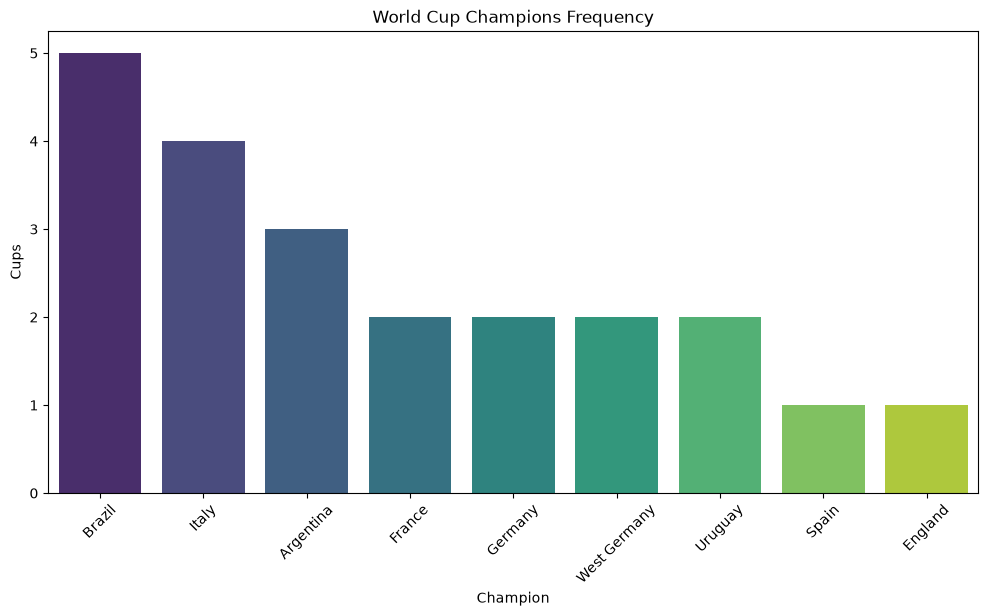

In [38]:
# World Cup summary
print('World Cup Data Head.')
print(world_cup.head().to_string(index=False))

# Display Championship
champion_table = world_cup.groupby('Champion')['Year'].apply(lambda x: sorted(x))
champion_table = champion_table.reset_index()
champion_table['Count'] = champion_table['Year'].apply(len)
champion_table = champion_table.sort_values('Count', ascending=False)[['Champion', 'Count', 'Year']]
champion_table = champion_table.reset_index(drop=True)

print("\nWorld Cup Champions Frequency")
print(champion_table)

champion_counts = world_cup['Champion'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=champion_counts.index, y=champion_counts.values, hue=champion_counts.index, palette='viridis', legend=False)
plt.title('World Cup Champions Frequency')
plt.xticks(rotation=45)
plt.xlabel('Champion')
plt.ylabel('Cups')
plt.show()

Display match dataset Date column info, after modifying.
count                           964
mean     1989-09-28 05:07:43.070539
min             1930-07-13 00:00:00
25%             1974-06-18 00:00:00
50%             1994-06-24 00:00:00
75%             2010-06-16 00:00:00
max             2022-12-18 00:00:00
Name: Date, dtype: object


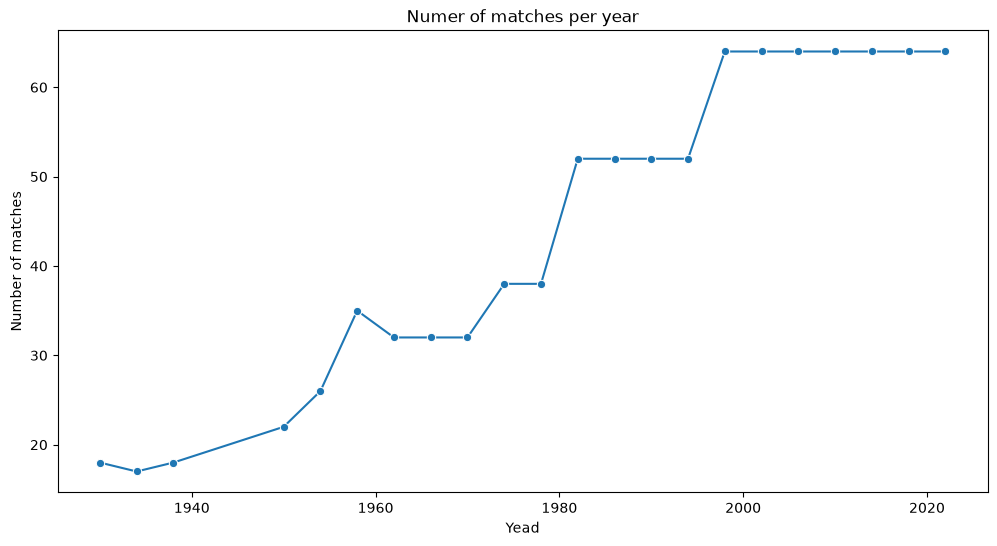

In [39]:
matches['Date'] = pd.to_datetime(matches['Date'], errors='coerce')
print("Display match dataset Date column info, after modifying.")
print(matches['Date'].describe())

# Display mathces per year
matches_per_year = matches.groupby('Year').size()
plt.figure(figsize=(12,6))
sns.lineplot(x=matches_per_year.index, y=matches_per_year.values, marker='o')
plt.title('Numer of matches per year')
plt.xlabel('Yead')
plt.ylabel('Number of matches')
plt.show()

In [40]:
schedule_2026['Date'] = pd.to_datetime(schedule_2026['Date'], errors='coerce')
print("Date schedules 2026 after modifying.")
print(schedule_2026['Date'].describe())

print(schedule_2026.head())

Date schedules 2026 after modifying.
count                     72
mean     2026-06-20 03:20:00
min      2026-06-11 00:00:00
25%      2026-06-16 00:00:00
50%      2026-06-20 12:00:00
75%      2026-06-24 06:00:00
max      2026-06-27 00:00:00
Name: Date, dtype: object
         Round  Day       Date           Time Score  Referee  Notes  Year  \
0  Group stage  Thu 2026-06-11  13:00 (22:00)   2-0      NaN    NaN  2026   
1  Group stage  Thu 2026-06-11  20:00 (05:00)   2-1      NaN    NaN  2026   
2  Group stage  Fri 2026-06-12  15:00 (22:00)   1-1      NaN    NaN  2026   
3  Group stage  Fri 2026-06-12  18:00 (04:00)   4-1      NaN    NaN  2026   
4  Group stage  Sat 2026-06-13  12:00 (22:00)   1-1      NaN    NaN  2026   

        home_team           away_team  
0          Mexico        South Africa  
1  Korea Republic             Czechia  
2          Canada  Bosnia-Herzegovina  
3   United States            Paraguay  
4           Qatar         Switzerland  
